In [1]:
# Load and Setup Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_DIR = "."
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_val   = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze("columns")
y_val   = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze("columns")
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

# Drop non-numeric columns
X_train = X_train.drop(columns=['Country Name', 'Year'])
X_val   = X_val.drop(columns=['Country Name', 'Year'])
X_test  = X_test.drop(columns=['Country Name', 'Year'])

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

def evaluate(model, X, y, label):
    pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    print(f"  {label:5s}  RMSE={rmse:10.3f}   MAE={mae:10.3f}   R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

Train: (1498, 12)  Val: (469, 12)  Test: (503, 12)


In [2]:
# Decision Tree Regression

dt_results = []
for depth in [3, 5, 7, 10, 15, 20, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    val_pred = dt.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2   = r2_score(y_val, val_pred)
    dt_results.append({"max_depth": depth, "val_rmse": val_rmse, "val_r2": val_r2})
    print(f"  max_depth={str(depth):>4s}   val RMSE={val_rmse:10.3f}   val R²={val_r2:.4f}")
 
dt_df = pd.DataFrame(dt_results)
best_dt_depth_raw = dt_df.loc[dt_df["val_rmse"].idxmin(), "max_depth"]
best_dt_depth = None if pd.isna(best_dt_depth_raw) else int(best_dt_depth_raw)
print(f"\n  → Best max_depth (lowest val RMSE): {best_dt_depth}")

best_dt = DecisionTreeRegressor(max_depth=best_dt_depth, random_state=42)
best_dt.fit(X_train, y_train)
print("Final Decision Tree performance:")
evaluate(best_dt, X_train, y_train, "Train")
evaluate(best_dt, X_val,   y_val,   "Val")
dt_test_metrics = evaluate(best_dt, X_test, y_test, "Test")

  max_depth=   3   val RMSE=  1057.635   val R²=0.0810
  max_depth=   5   val RMSE=   886.197   val R²=0.3548
  max_depth=   7   val RMSE=   871.361   val R²=0.3762
  max_depth=  10   val RMSE=   872.602   val R²=0.3744
  max_depth=  15   val RMSE=   871.530   val R²=0.3760
  max_depth=  20   val RMSE=   888.328   val R²=0.3517
  max_depth=None   val RMSE=   883.885   val R²=0.3582

  → Best max_depth (lowest val RMSE): 7
Final Decision Tree performance:
  Train  RMSE=    38.256   MAE=    21.039   R²=0.9990
  Val    RMSE=   871.361   MAE=   223.169   R²=0.3762
  Test   RMSE=   316.008   MAE=   129.782   R²=0.3180


In [3]:
# Random Forest Regression

rf_results = []
for n_est in [100, 300]:
    for depth in [10, 20, None]:
        for min_leaf in [1, 2]:
            rf = RandomForestRegressor(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=min_leaf,
                n_jobs=-1,
                random_state=42,
            )
            rf.fit(X_train, y_train)
            val_pred = rf.predict(X_val)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
            val_r2   = r2_score(y_val, val_pred)
            rf_results.append({
                "n_estimators": n_est, "max_depth": depth,
                "min_samples_leaf": min_leaf,
                "val_rmse": val_rmse, "val_r2": val_r2,
            })
            print(f"  n_est={n_est:3d}  depth={str(depth):>4s}  "
                  f"min_leaf={min_leaf}   val RMSE={val_rmse:10.3f}   val R²={val_r2:.4f}")
 
rf_df = pd.DataFrame(rf_results)
best_rf_row = rf_df.loc[rf_df["val_rmse"].idxmin()]
print(f"\n  → Best RF config: {best_rf_row.to_dict()}")

best_rf = RandomForestRegressor(
    n_estimators=int(best_rf_row["n_estimators"]),
    max_depth=None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"]),
    min_samples_leaf=int(best_rf_row["min_samples_leaf"]),
    n_jobs=-1,
    random_state=42,
)
best_rf.fit(X_train, y_train)
print("Final Random Forest performance:")
evaluate(best_rf, X_train, y_train, "Train")
evaluate(best_rf, X_val,   y_val,   "Val")
rf_test_metrics = evaluate(best_rf, X_test, y_test, "Test")

  n_est=100  depth=  10  min_leaf=1   val RMSE=   883.268   val R²=0.3591
  n_est=100  depth=  10  min_leaf=2   val RMSE=   883.448   val R²=0.3588
  n_est=100  depth=  20  min_leaf=1   val RMSE=   883.494   val R²=0.3587
  n_est=100  depth=  20  min_leaf=2   val RMSE=   885.571   val R²=0.3557
  n_est=100  depth=None  min_leaf=1   val RMSE=   884.297   val R²=0.3576
  n_est=100  depth=None  min_leaf=2   val RMSE=   885.433   val R²=0.3559
  n_est=300  depth=  10  min_leaf=1   val RMSE=   880.737   val R²=0.3627
  n_est=300  depth=  10  min_leaf=2   val RMSE=   878.931   val R²=0.3653
  n_est=300  depth=  20  min_leaf=1   val RMSE=   879.886   val R²=0.3640
  n_est=300  depth=  20  min_leaf=2   val RMSE=   882.071   val R²=0.3608
  n_est=300  depth=None  min_leaf=1   val RMSE=   880.932   val R²=0.3624
  n_est=300  depth=None  min_leaf=2   val RMSE=   879.094   val R²=0.3651

  → Best RF config: {'n_estimators': 300.0, 'max_depth': 10.0, 'min_samples_leaf': 2.0, 'val_rmse': 878.9310774

In [ ]:
# Feature Importances & Outputs

imp = pd.Series(best_rf.feature_importances_, index=X_train_enc.columns)
non_country = imp[~imp.index.str.startswith("country_")].sort_values(ascending=False)

print("TOP 5 features:")
print(non_country.head(5).to_string(float_format=lambda x: f"{x:.4f}"))
print()
print("BOTTOM 5 features:")
print(non_country.tail(5).to_string(float_format=lambda x: f"{x:.4f}"))

country_avg = (
    df.groupby('Country Name')['carbon_emissions']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

print("\nTop 5 Worst (highest average CO2 emissions):")
print(country_avg.head(5).to_string(float_format=lambda x: f"{x:,.2f}"))
print()
print("Top 5 Best (lowest average CO2 emissions):")
print(country_avg.tail(5).sort_values().to_string(float_format=lambda x: f"{x:,.2f}"))

TOP 5 features:
Urban population                                             0.7194
Net trade in goods and services (BoP, current US$)           0.0637
Electric power consumption (kWh per capita)                  0.0177
Agriculture, forestry, and fishing, value added (% of GDP)   0.0144
Urban population (% of total population)                     0.0110

BOTTOM 5 features:
Fossil fuel energy consumption (% of total)                0.0016
Energy imports, net (% of energy use)                      0.0016
Electricity production from nuclear sources (% of total)   0.0014
Year                                                       0.0013
Access to electricity (% of population)                    0.0009

Top 5 Worst (highest average CO2 emissions):
Country Name
China                9,374.91
United States        5,277.96
India                1,973.33
Russian Federation   1,791.26
Japan                1,198.22

Top 5 Best (lowest average CO2 emissions):
Country Name
Nauru                      0

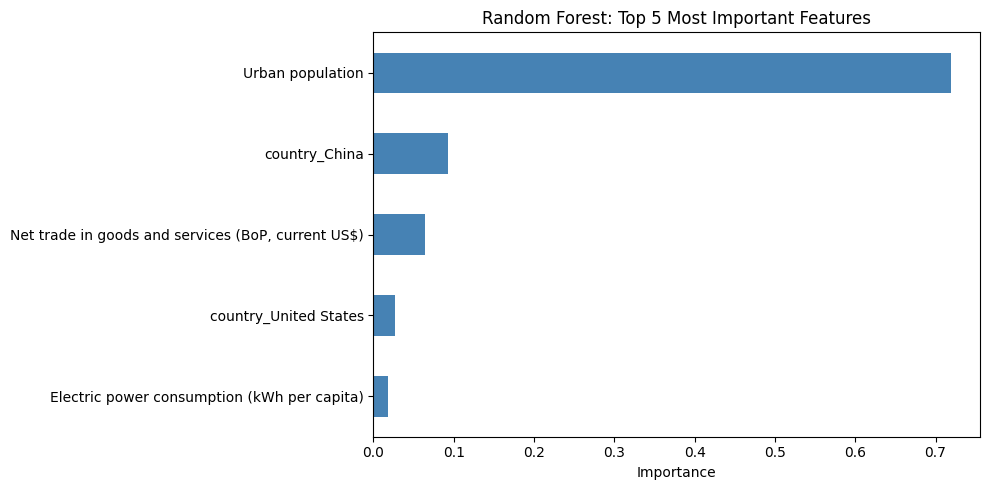

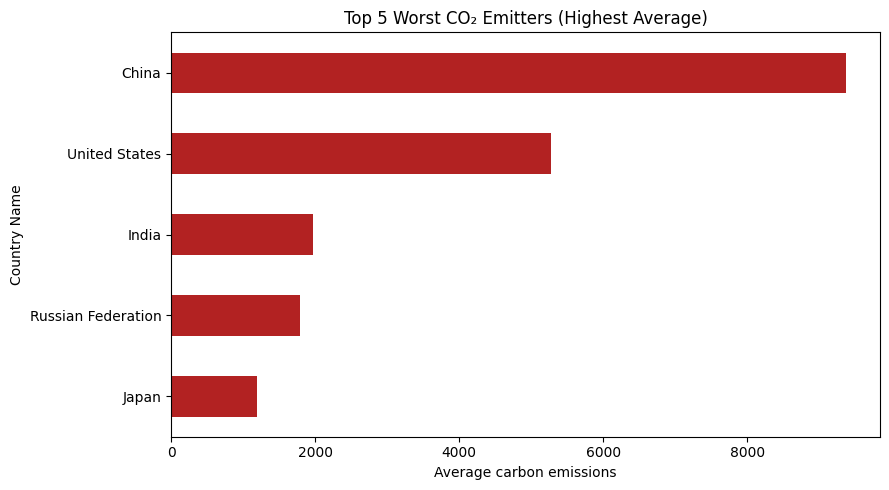

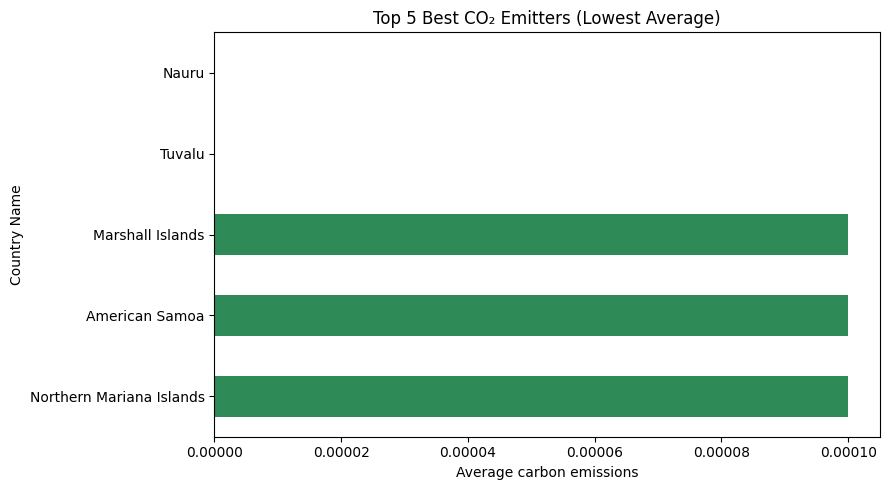

In [ ]:
# Plots

imp = (
    pd.Series(best_rf.feature_importances_, index=X_train_enc.columns)
    .sort_values(ascending=False)
)
top5 = imp.head(5)

plt.figure(figsize=(10, 5))
top5[::-1].plot(kind='barh', color='steelblue')
plt.title('Random Forest: Top 5 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

country_avg = (
    df.groupby('Country Name')['carbon_emissions']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

worst5 = country_avg.head(5)

plt.figure(figsize=(9, 5))
worst5[::-1].plot(kind='barh', color='firebrick')
plt.title('Top 5 Worst CO₂ Emitters (Highest Average)')
plt.xlabel('Average carbon emissions')
plt.tight_layout()
plt.show()

best5 = country_avg.tail(5).sort_values()

plt.figure(figsize=(9, 5))
best5[::-1].plot(kind='barh', color='seagreen')
plt.title('Top 5 Best CO₂ Emitters (Lowest Average)')
plt.xlabel('Average carbon emissions')
plt.tight_layout()
plt.show()